# Uczenie reprezentacji wielokanałowego EEG do klasyfikacji choroby Alzheimera

**Raport końcowy — projekt zespołowy (Uczenie Reprezentacji)**

| Osoba | Wkład | Sekcje |
|---|---|---|
| **Filip** | Potok danych (preprocessing, czyszczenie, cięcie EEG), infrastruktura repozytorium (DVC), baseline (Autoenkoder) | 2, 3 |
| **Damian** | Definicja, adaptacja i trening dwóch modeli kontrastywnych (TNC, CPC) + klasyfikacja liniowa | 4, 5, 7 |
| **Jakub** | Model przestrzeni stanów Mamba, ewaluacja końcowa, badanie hiperparametrów struktur sieciowych | 6 |

---
# 1. Opis problemu

### 1.1. Dane wejściowe
Wielokanałowe sygnały **EEG** ze zbioru **BrainLat**. Surowe nagrania (EEGLAB `.set`) są cięte na **okna 3-sekundowe** i zapisywane jako tensory PyTorch — jeden plik na pacjenta, kształt `(liczba_okien, 128 kanałów, 1536 próbek)`. Okna zachowują **kolejność czasową**, co jest kluczowe dla metod kontrastywnych wykorzystujących strukturę czasu.

### 1.2. Dane wyjściowe
Binarna etykieta diagnozy: **AD** (Alzheimer, `1`) vs **CN** (grupa kontrolna, `0`). Zbiór: **67 pacjentów** (32 CN, 35 AD).

### 1.3. Typ problemu
**Klasyfikacja binarna.** Reprezentacje uczone są **bez etykiet** (samonadzorowanie); etykiety wchodzą dopiero na etapie *klasyfikacji liniowej* (linear evaluation).

### 1.4. Hipoteza badawcza
> Reprezentacje wyuczone metodami kontrastywnymi (TNC, CPC), wykorzystującymi **strukturę czasową** EEG, dadzą cechy lepiej rozdzielające klasy AD/CN niż naiwny baseline (Autoenkoder rekonstrukcyjny) — mierzone wyższym **ROC-AUC** w klasyfikacji liniowej.

### 1.5. Czym jest "klasyfikacja liniowa" (linear evaluation)
Standardowy protokół oceny reprezentacji w uczeniu samonadzorowanym:
1. enkoder uczy się **bez etykiet**;
2. enkoder jest **zamrażany** (wagi nie zmieniają się);
3. na zamrożonych cechach trenujemy **wyłącznie prosty klasyfikator** (liniowy / płytka głowica);
4. mierzymy AUC/accuracy.

Jeśli słaby klasyfikator liniowy potrafi rozdzielić klasy na danych cechach, to znaczy, że **enkoder nauczył się użytecznej, liniowo separowalnej reprezentacji**. Liniowość izoluje wkład samego enkodera.

---
# 2. Dane: wczytanie, preprocessing, przygotowanie
### *(sekcja Filipa — poniżej struktura do uzupełnienia)*

**Do opisania:**
- Źródło i charakterystyka zbioru BrainLat (liczba pacjentów, kanały, częstotliwość próbkowania, długość nagrań).
- Kroki preprocessingu: wczytanie (MNE), filtrowanie częstotliwościowe, usuwanie artefaktów, cięcie na okna 3 s, normalizacja.
- Format wyjściowy (`data/processed/*.pt`), mapowanie etykiet (AD=1, CN=0).
- Podział danych: `StratifiedGroupKFold` na poziomie pacjenta (brak data leakage).

In [1]:
# (Filip) miejsce na kod preprocessingu / wczytania surowych danych, jeśli ma być w raporcie.
# Przetworzone dane są już dostępne w data/processed/*.pt i wczytywane w sekcji 3.1 poniżej.

---
# 3. Baseline — Autoenkoder
### *(sekcja Filipa — kod i struktura przygotowane, do opisania słownie)*

**Do opisania:**
- **Krótki opis:** konwolucyjny Autoenkoder uczony rekonstrukcją (MSE); enkoder `Conv1d→BN→ReLU→MaxPool` ×2.
- **Odpalenie dla domyślnych wartości** + klasyfikacja liniowa (AUC/acc po foldach) — kod w 3.2.
- **Wyniki i wnioski** — punkt odniesienia (*naiwny baseline*) dla metod kontrastywnych z sekcji 4–5.

Funkcje pomocnicze i wczytanie danych (sekcja 3.1) są współdzielone z częścią Damiana — definiujemy je raz, niżej.

## 3.1. Konfiguracja, wczytanie danych i funkcje wspólne
*(współdzielone przez sekcje 3–5)*

In [2]:
import os, sys, glob, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.models.cpc import CPCModel
from src.models.tnc import TNCModel
from src.models.mamba_model import MambaModel
from src.models.baseline_ae import Autoencoder
from src.models.linear_classifier import LinearClassifier
from src.data.dataloaders import get_fold_sequence_dataloaders, get_fold_dataloaders
from src.evaluation.encoders import build_encoder
# Wspólna logika treningu SSL i klasyfikacji liniowej — to samo źródło, którego używają
# skrypty CLI src/training/train_cpc.py i train_tnc.py (jedno miejsce prawdy, brak duplikacji).
from src.training.ssl_training import train_ssl as _train_ssl, linear_probe as _linear_probe

DATA_DIR = os.path.join(ROOT, 'data', 'processed')
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
#DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print('ROOT      :', ROOT)
print('Urządzenie:', DEVICE)
print('Pliki .pt :', len(glob.glob(os.path.join(DATA_DIR, '*.pt'))))

ROOT      : /Users/jakubsmolarczyk/Desktop/katalogi/pythons/Alzheimer-classifier
Urządzenie: mps
Pliki .pt : 67


**Przełącznik trybu.** Trening na CPU jest wolny. `QUICK=True` → szybki przebieg do weryfikacji poprawności; `QUICK=False` → pełne wyniki do sprawozdania (najlepiej GPU).

**Zapisywanie / wczytywanie (dla współpracy i DVC).** Wytrenowane enkodery zapisują się do `models/representations/<wariant>/encoder_fold_*.pth` (→ DVC), a wyniki liczbowe (historie, tabele) do `notebooks/results/*.{json,csv}` (→ git). Gdy `LOAD_PRETRAINED=True` i pliki są na dysku (np. po `dvc pull` + `git pull`), notebook **wczytuje gotowe wyniki i NIE trenuje** — inna osoba odtwarza raport bez kosztownego treningu.

In [3]:
QUICK = False            # <-- False dla pełnego eksperymentu (najlepiej GPU)
LOAD_PRETRAINED = True   # <-- True: wczytuj gotowe wyniki/wagi jeśli są; False: zawsze trenuj od zera

if QUICK:
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS, RS_TRIALS = 2, 3, 10, 4
else:
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS, RS_TRIALS = 5, 30, 30, 12

RESULTS_DIR = os.path.join(ROOT, 'notebooks', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Tryb: {"SZYBKI" if QUICK else "PEŁNY"} | n_splits={N_SPLITS} ssl_epochs={SSL_EPOCHS} '
      f'probe_epochs={PROBE_EPOCHS} rs_trials={RS_TRIALS} | LOAD_PRETRAINED={LOAD_PRETRAINED}')

Tryb: PEŁNY | n_splits=5 ssl_epochs=30 probe_epochs=30 rs_trials=12 | LOAD_PRETRAINED=True


Pacjentów: 67  (CN=32, AD=35)
Kształt pacjenta: (200, 128, 1536)  -> (okna, kanały, próbki)
Okien/pacjenta: min=47 max=225 śr=148
Fold 0: 53 train / 14 val pacjentów | leakage: 0 (musi być 0)


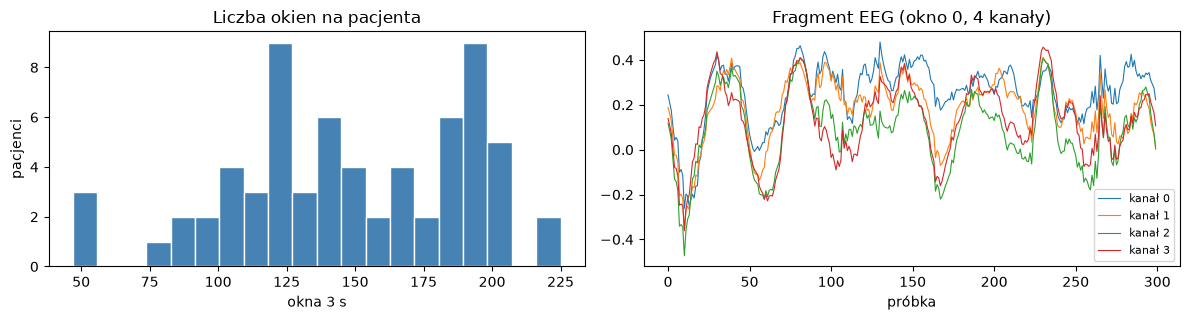

In [4]:
# --- Inspekcja danych: kształt, rozkład klas, brak przecieku pacjentów ---
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.pt')))
labels = [int(os.path.basename(f).split('_label_')[1].replace('.pt','')) for f in files]
n_per_patient = [torch.load(f).shape[0] for f in files]
ex = torch.load(files[0])

print(f'Pacjentów: {len(files)}  (CN={labels.count(0)}, AD={labels.count(1)})')
print(f'Kształt pacjenta: {tuple(ex.shape)}  -> (okna, kanały, próbki)')
print(f'Okien/pacjenta: min={min(n_per_patient)} max={max(n_per_patient)} śr={np.mean(n_per_patient):.0f}')

fold0, tl_seq, vl_seq = next(get_fold_sequence_dataloaders(DATA_DIR, n_splits=N_SPLITS))
leak = set(tl_seq.dataset.subjects) & set(vl_seq.dataset.subjects)
print(f'Fold 0: {len(tl_seq)} train / {len(vl_seq)} val pacjentów | leakage: {len(leak)} (musi być 0)')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].hist(n_per_patient, bins=20, color='steelblue', edgecolor='white')
ax[0].set_title('Liczba okien na pacjenta'); ax[0].set_xlabel('okna 3 s'); ax[0].set_ylabel('pacjenci')
for ch in range(4):
    ax[1].plot(ex[0, ch, :300].numpy(), lw=0.8, label=f'kanał {ch}')
ax[1].set_title('Fragment EEG (okno 0, 4 kanały)'); ax[1].set_xlabel('próbka'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Metryki i funkcje wspólne

- **ROC-AUC** (wiodąca) i **Accuracy**, średnia ± std po foldach `StratifiedGroupKFold`.
- `linear_probe()` — klasyfikacja liniowa na zamrożonym enkoderze.
- `train_ssl()` — uczenie reprezentacji kontrastywnej (TNC/CPC).
- `run_cv_smart()` — train-or-load: wczytuje zapisane wyniki/wagi albo trenuje i zapisuje.
- `hp_study()` / `random_search()` — badanie hiperparametru i losowe przeszukiwanie (oba z cache wyników).

In [5]:
# ---------- zapis / odczyt lekkich wyników (-> git) ----------
def _res(name): return os.path.join(RESULTS_DIR, name)
def save_json(o, name):
    with open(_res(name), 'w', encoding='utf-8') as f: json.dump(o, f)
def load_json(name):
    with open(_res(name), 'r', encoding='utf-8') as f: return json.load(f)
def save_df(df, name): df.to_csv(_res(name), index=False)
def load_df(name): return pd.read_csv(_res(name))
def results_exist(*names): return all(os.path.exists(_res(n)) for n in names)

# ---------- zapis / odczyt wag enkoderów (-> DVC) ----------
def _enc_path(variant, fold):
    return os.path.join(ROOT, 'models', 'representations', variant, f'encoder_fold_{fold}.pth')
def save_encoder(model, variant, fold):
    os.makedirs(os.path.dirname(_enc_path(variant, fold)), exist_ok=True)
    torch.save(model.encoder.state_dict(), _enc_path(variant, fold)); return _enc_path(variant, fold)
def all_encoders_exist(variant, n_splits):
    return all(os.path.exists(_enc_path(variant, f)) for f in range(n_splits))

# ---------- trening SSL i klasyfikacja liniowa ----------
# Rdzeń (pętla treningu, probe) jest w src/training/ssl_training.py — to SAMO źródło, którego
# używają skrypty CLI train_cpc.py / train_tnc.py. Tu tylko cienkie wrappery dokładające DEVICE.
def train_ssl(model, seq_loader, epochs, lr=1e-3, verbose=True):
    return _train_ssl(model, seq_loader, epochs, DEVICE, lr=lr, verbose=verbose)

def linear_probe(encoder, encoded_size, tl, vl, epochs, lr=5e-3):
    return _linear_probe(encoder, encoded_size, tl, vl, epochs, DEVICE, lr=lr)

# ---------- pełne CV ----------
def run_cv(model_factory, ssl_epochs, n_splits, probe_epochs, lr_ssl=1e-3, verbose=True, save_variant=None):
    accs, aucs, hists = [], [], []
    seq_gen = get_fold_sequence_dataloaders(DATA_DIR, n_splits=n_splits)
    win_gen = get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64)
    for (fold, tl_seq, _), (_, tl_win, vl_win) in zip(seq_gen, win_gen):
        s, _ = next(iter(tl_seq)); C, T = s.shape[1], s.shape[2]
        if verbose: print(f'--- FOLD {fold} (trening) ---')
        m = model_factory(C, T)
        h = train_ssl(m, tl_seq, ssl_epochs, lr=lr_ssl, verbose=verbose)
        if save_variant: save_encoder(m, save_variant, fold)
        m.encoder.eval()
        acc, auc = linear_probe(m.encoder, m.encoded_size, tl_win, vl_win, probe_epochs)
        if verbose: print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}')
        accs.append(acc); aucs.append(auc); hists.append(h)
    return accs, aucs, hists

def run_cv_pretrained(variant, model_name, n_splits, probe_epochs, verbose=True):
    """Wczytuje gotowe enkodery (bez treningu SSL), robi tylko klasyfikację liniową."""
    accs, aucs = [], []
    for fold, tl_win, vl_win in get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64):
        s, _ = next(iter(tl_win)); C, T = s.shape[1], s.shape[2]
        enc, es = build_encoder(model_name, C, T, DEVICE)
        enc.load_state_dict(torch.load(_enc_path(variant, fold), map_location=DEVICE)); enc.eval()
        if verbose: print(f'--- FOLD {fold} (wczytano {variant}/encoder_fold_{fold}.pth) ---')
        acc, auc = linear_probe(enc, es, tl_win, vl_win, probe_epochs)
        if verbose: print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}')
        accs.append(acc); aucs.append(auc)
    return accs, aucs, []

def run_cv_smart(model_factory, model_name, variant, ssl_epochs, n_splits, probe_epochs,
                 lr_ssl=1e-3, hist_file=None, res_file=None):
    """Train-or-load: (1) są zapisane wyniki -> wczytaj; (2) są wagi -> wczytaj+linear-probe;
    (3) brak -> trenuj od zera i zapisz wagi+wyniki."""
    if LOAD_PRETRAINED and res_file and results_exist(res_file):
        r = load_json(res_file)
        hist = load_json(hist_file) if (hist_file and results_exist(hist_file)) else []
        print(f'[{variant.upper()}] Wczytano zapisane wyniki ({res_file}) — bez treningu.')
        return r['accs'], r['aucs'], hist
    if LOAD_PRETRAINED and all_encoders_exist(variant, n_splits):
        print(f'[{variant.upper()}] Wczytuję gotowe enkodery (wagi) — bez treningu SSL.')
        accs, aucs, hist = run_cv_pretrained(variant, model_name, n_splits, probe_epochs)
    else:
        if LOAD_PRETRAINED: print(f'[{variant.upper()}] Brak zapisanych wyników/wag -> trening od zera.')
        accs, aucs, hist = run_cv(model_factory, ssl_epochs, n_splits, probe_epochs, lr_ssl=lr_ssl, save_variant=variant)
    if res_file: save_json({'accs': accs, 'aucs': aucs}, res_file)
    if hist_file and hist: save_json(hist, hist_file)
    return accs, aucs, hist

# ---------- badanie HP i random search (fold 0; oba z cache) ----------
def eval_single_fold(model_factory, ssl_epochs, probe_epochs, lr_ssl=1e-3, verbose=False):
    _, tl_seq, _ = next(get_fold_sequence_dataloaders(DATA_DIR, n_splits=N_SPLITS))
    _, tl_win, vl_win = next(get_fold_dataloaders(DATA_DIR, n_splits=N_SPLITS, batch_size=64))
    s, _ = next(iter(tl_seq)); C, T = s.shape[1], s.shape[2]
    m = model_factory(C, T); train_ssl(m, tl_seq, ssl_epochs, lr=lr_ssl, verbose=verbose); m.encoder.eval()
    return linear_probe(m.encoder, m.encoded_size, tl_win, vl_win, probe_epochs)

def hp_study(build_model, param_name, grid, fixed, res_file):
    if LOAD_PRETRAINED and results_exist(res_file):
        print(f'Wczytano zapisaną tabelę badania HP ({res_file}).'); return load_df(res_file)
    rows = []
    for val in grid:
        print(f'[{param_name} = {val}]')
        params = {**fixed, param_name: val}
        acc, auc = eval_single_fold(lambda C, T, p=params: build_model(C, T, **p), SSL_EPOCHS, PROBE_EPOCHS)
        rows.append({param_name: val, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)})
    df = pd.DataFrame(rows); save_df(df, res_file); return df

def random_search(build_model, param_space, n_trials, res_file, seed=0):
    if LOAD_PRETRAINED and results_exist(res_file):
        print(f'Wczytano zapisaną tabelę random search ({res_file}).'); return load_df(res_file)
    rng = np.random.RandomState(seed); rows = []
    for i in range(n_trials):
        params = {}
        for k, v in param_space.items():
            val = v[int(rng.randint(len(v)))]
            params[k] = val.item() if hasattr(val, 'item') else val
        acc, auc = eval_single_fold(lambda C, T, p=params: build_model(C, T, **p), SSL_EPOCHS, PROBE_EPOCHS)
        rows.append({**params, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)})
        print(f'  trial {i+1}/{n_trials}: {params} -> AUC {auc:.4f}')
    df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    save_df(df, res_file); return df

def best_params_from(rs_df, int_keys):
    """Wyciąga najlepszy zestaw HP z tabeli random search (bez kolumn metryk), rzutując wybrane na int."""
    p = {k: rs_df.iloc[0][k] for k in rs_df.columns if k not in ('Accuracy', 'ROC-AUC')}
    for k in int_keys:
        if k in p: p[k] = int(p[k])
    return p

def fmt(vals): return f'{np.mean(vals):.3f} ± {np.std(vals):.3f}'
def plot_hist(hists, title, msg):
    if hists:
        plt.figure(figsize=(6, 3.3))
        for i, h in enumerate(hists): plt.plot(range(1, len(h)+1), h, marker='o', alpha=0.7, label=f'fold {i}')
        plt.title(title); plt.xlabel('epoka'); plt.ylabel('loss'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
    else:
        print(msg)

## 3.2. Trening baseline'u (AE) + klasyfikacja liniowa

In [6]:
def run_cv_ae(epochs, n_splits, probe_epochs, lr=1e-3, res_file='ae_default.json'):
    if LOAD_PRETRAINED and results_exist(res_file):
        r = load_json(res_file); print(f'[AE] Wczytano zapisane wyniki ({res_file}).'); return r['accs'], r['aucs']
    accs, aucs = [], []
    for fold, tl, vl in get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64):
        s, _ = next(iter(tl)); C, T = s.shape[1], s.shape[2]
        print(f'--- FOLD {fold} (AE) ---')
        ae = Autoencoder(C, T).to(DEVICE); crit = nn.MSELoss(); opt = optim.Adam(ae.parameters(), lr=lr)
        for ep in range(epochs):
            ae.train()
            for X, _ in tl:
                X = X.to(DEVICE); opt.zero_grad(); _, rec = ae(X)
                if rec.shape[2] != X.shape[2]: rec = nn.functional.interpolate(rec, size=X.shape[2])
                crit(rec, X).backward(); opt.step()
        save_encoder(ae, 'ae', fold); ae.encoder.eval()
        acc, auc = linear_probe(ae.encoder, ae.encoded_size, tl, vl, probe_epochs)
        print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}'); accs.append(acc); aucs.append(auc)
    save_json({'accs': accs, 'aucs': aucs}, res_file); return accs, aucs

print('=== Baseline AE ===')
ae_acc, ae_auc = run_cv_ae(SSL_EPOCHS, N_SPLITS, PROBE_EPOCHS)
print(f'\nAE | Acc {fmt(ae_acc)} | AUC {fmt(ae_auc)}')

=== Baseline AE ===
[AE] Wczytano zapisane wyniki (ae_default.json).

AE | Acc 0.498 ± 0.004 | AUC 0.493 ± 0.007


---
# 4. TNC — Temporal Neighborhood Coding

## 4.1. Krótki opis
- **Publikacja:** Tonekaboni, Eytan, Goldenberg, *Unsupervised Representation Learning for Time Series with Temporal Neighborhood Coding*, ICLR 2021 (arXiv:2106.00750).
- **Idea:** dla okna kotwicznego `t` okna z **sąsiedztwa czasowego** są pozytywne, a odległe — negatywne. Dyskryminator uczy się je rozróżniać, co wymusza spójność reprezentacji w czasie. Oryginał stosuje **PU-learning**: odległe okna są *nieoznaczone* → strata negatywna ważona współczynnikiem `w`.
- **Nasza adaptacja:** enkoder splotowy 1D **identyczny z baseline'em AE** (uczciwe porównanie). Sąsiedztwo = promień `neighbor_range` (uproszczenie wobec okna ADF-stationarity). Implementacja: `src/models/tnc.py`.

**Hiperparametry:** `neighbor_range`, `num_samples`, `w`.

## 4.2. Odpalenie dla wartości domyślnych

In [ ]:
print('=== TNC (domyślne: neighbor_range=3, num_samples=5, w=0.05) ===')
t0 = time.time()
tnc_acc, tnc_auc, tnc_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, neighbor_range=3, num_samples=5, w=0.05),
    model_name='tnc', variant='tnc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='tnc_default_hist.json', res_file='tnc_default.json',
)
print(f'\nTNC (domyślny) | Acc {fmt(tnc_acc)} | AUC {fmt(tnc_auc)}  ({time.time()-t0:.0f}s)')

In [ ]:
plot_hist(tnc_hist, 'TNC — strata dyskryminatora',
          'Wczytano gotowe wyniki — brak historii treningu (ustaw LOAD_PRETRAINED=False, by ją zobaczyć).')

## 4.3. Badanie hiperparametru — `neighbor_range`

Promień sąsiedztwa decyduje, jak "blisko" w czasie okna uznajemy za podobne. Badamy wpływ na ROC-AUC (fold 0). Wynik zapisywany do `results/tnc_hp.csv`.

In [ ]:
tnc_hp_df = hp_study(lambda C, T, **p: TNCModel(C, T, **p),
                     'neighbor_range', [1, 3, 5, 10], {'num_samples': 5, 'w': 0.05}, 'tnc_hp.csv')
tnc_hp_df

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.plot(tnc_hp_df['neighbor_range'], tnc_hp_df['ROC-AUC'], marker='o', color='indianred', label='ROC-AUC')
plt.plot(tnc_hp_df['neighbor_range'], tnc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('TNC — wpływ neighbor_range'); plt.xlabel('neighbor_range'); plt.ylabel('metryka (fold 0)')
plt.legend(); plt.tight_layout(); plt.show()

## 4.4. Random search optymalnych hiperparametrów

Losowe przeszukiwanie przestrzeni hiperparametrów, wybór po najwyższym **AUC klasyfikacji liniowej** (fold 0). Wynik w `results/tnc_rs.csv`.

In [ ]:
tnc_space = {'neighbor_range': [1, 2, 3, 5, 8, 10], 'num_samples': [3, 5, 8, 10], 'w': [0.01, 0.05, 0.1, 0.2]}
print('=== TNC random search ===')
tnc_rs = random_search(lambda C, T, **p: TNCModel(C, T, **p), tnc_space, RS_TRIALS, 'tnc_rs.csv', seed=0)
tnc_rs

### TNC z najlepszymi hiperparametrami — pełne CV
Najlepszy zestaw z random search dotrenowujemy na **pełnym CV** (wariant `tnc_best`). Ten wynik trafia do tabeli porównawczej (sekcja 7) obok domyślnego.

In [ ]:
tnc_best_params = best_params_from(tnc_rs, int_keys=('neighbor_range', 'num_samples'))
print('Najlepsze HP TNC:', tnc_best_params)
t0 = time.time()
tnc_best_acc, tnc_best_auc, tnc_best_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, **tnc_best_params),
    model_name='tnc', variant='tnc_best', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='tnc_best_hist.json', res_file='tnc_best.json',
)
print(f'\nTNC (najlepszy) | Acc {fmt(tnc_best_acc)} | AUC {fmt(tnc_best_auc)}  ({time.time()-t0:.0f}s)')

## 4.5. Wyniki i wnioski — TNC
*(do uzupełnienia liczbami po `QUICK=False`)*
- Domyślny TNC vs baseline AE (sekcja 7): czy reprezentacja sąsiedztwa czasowego daje przewagę?
- `neighbor_range`: która wartość maksymalizuje AUC i dlaczego?
- Zysk z optymalizacji: najlepszy zestaw z random search względem domyślnego.

---
# 5. CPC — Contrastive Predictive Coding

## 5.1. Krótki opis
- **Publikacja:** van den Oord, Li, Vinyals, *Representation Learning with Contrastive Predictive Coding*, arXiv:1807.03748 (2018).
- **Idea:** enkoder `g_enc` koduje okno do `z_t`; autoregresor `g_ar` (**GRU**) buduje kontekst `c_t`. Dla horyzontu `k` projekcja `W_k` przewiduje `z_{t+k}`. Trening stratą **InfoNCE**.
- **Nasza adaptacja:** enkoder splotowy **identyczny z AE/TNC**. Negatywy losowane wewnątrz sekwencji jednego pacjenta. Implementacja: `src/models/cpc.py`.

**Hiperparametry:** `prediction_steps`, `context_dim`.

## 5.2. Odpalenie dla wartości domyślnych

In [ ]:
print('=== CPC (domyślne: context_dim=128, prediction_steps=4) ===')
t0 = time.time()
cpc_acc, cpc_auc, cpc_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, context_dim=128, prediction_steps=4),
    model_name='cpc', variant='cpc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='cpc_default_hist.json', res_file='cpc_default.json',
)
print(f'\nCPC (domyślny) | Acc {fmt(cpc_acc)} | AUC {fmt(cpc_auc)}  ({time.time()-t0:.0f}s)')

In [ ]:
plot_hist(cpc_hist, 'CPC — strata InfoNCE',
          'Wczytano gotowe wyniki — brak historii treningu (ustaw LOAD_PRETRAINED=False, by ją zobaczyć).')

## 5.3. Badanie hiperparametru — `prediction_steps`

Liczba kroków predykcji w przód. Większa wartość = dłuższe zależności czasowe, ale trudniejsze zadanie. Wynik w `results/cpc_hp.csv`.

In [ ]:
cpc_hp_df = hp_study(lambda C, T, **p: CPCModel(C, T, **p),
                     'prediction_steps', [1, 2, 4, 8], {'context_dim': 128}, 'cpc_hp.csv')
cpc_hp_df

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['ROC-AUC'], marker='o', color='steelblue', label='ROC-AUC')
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('CPC — wpływ prediction_steps'); plt.xlabel('prediction_steps'); plt.ylabel('metryka (fold 0)')
plt.legend(); plt.tight_layout(); plt.show()

## 5.4. Random search optymalnych hiperparametrów
Wynik w `results/cpc_rs.csv`.

In [ ]:
cpc_space = {'prediction_steps': [1, 2, 4, 6, 8, 12], 'context_dim': [32, 64, 128, 256]}
print('=== CPC random search ===')
cpc_rs = random_search(lambda C, T, **p: CPCModel(C, T, **p), cpc_space, RS_TRIALS, 'cpc_rs.csv', seed=0)
cpc_rs

### CPC z najlepszymi hiperparametrami — pełne CV
Najlepszy zestaw z random search dotrenowany na **pełnym CV** (wariant `cpc_best`).

In [ ]:
cpc_best_params = best_params_from(cpc_rs, int_keys=('prediction_steps', 'context_dim'))
print('Najlepsze HP CPC:', cpc_best_params)
t0 = time.time()
cpc_best_acc, cpc_best_auc, cpc_best_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, **cpc_best_params),
    model_name='cpc', variant='cpc_best', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='cpc_best_hist.json', res_file='cpc_best.json',
)
print(f'\nCPC (najlepszy) | Acc {fmt(cpc_best_acc)} | AUC {fmt(cpc_best_auc)}  ({time.time()-t0:.0f}s)')

## 5.5. Wyniki i wnioski — CPC
*(do uzupełnienia liczbami po `QUICK=False`)*
- Domyślny CPC vs baseline AE: czy predykcja przyszłości daje lepsze cechy?
- `prediction_steps`: optymalny horyzont.
- Zysk z optymalizacji względem domyślnego.

---
# 6. Mamba — model przestrzeni stanów

## 6.1. Krótki opis
- **Publikacja:** Albert Gu and Tri Dao, *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*, arXiv:2312.00752 (2024). Dodatkowo, [ciekawy blog o mamba](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-mamba-and-state)
- **Idea:** `MambaEncoder` koduje każde okno EEG wewnętrznie – SSM przetwarza patche i akumuluje stan ukryty `h_t` wewnątrz okna, produkując reprezentację `z_t` przez pobranie ostatniego tokenu. Projekcja liniowa przewiduje `z_{t+k}` na podstawie `z_t`. Trening stratą InfoNCE. Negatywy losowane sa wewnątrz sekwencji jednego pacjenta.
- **Uproszczenia względem mamby:**
  * Jawna pętla Python po wymiarze czasowym zamiast równoległego CUDA kernel – poprawna matematycznie, wolniejsza obliczeniowo.
  * 2 bloki Mamby zamiast standardowych 24–48, uzasadnione małym rozmiarem datasetu.
- **Adaptacja pod sygnał EEG:**
  * Wejście (B, 128, 1536). _EEGPatchEmbed tworzy 12 patchy per okno, każdy reprezentujący wycinek sygnału ze wszystkich kanałów jednocześnie.
  * `_pool` pobiera ostatni token `z[:, -1, :]` – ostatni token SSM zawiera zakumulowany stan ukryty całego okna.

Implementacja: `src/models/mamba_model.py`.

**Hiperparametry:** `d_model` - wymiar przestrzeni reprezentacji, `d_state` - pojemność pamięci SSM.

## 6.2. Odpalenie dla wartości domyślnych

In [6]:
print('=== Mamba (domyślne: d_model=64, d_state=16) ===')
t0 = time.time()
mamba_acc, mamba_auc, mamba_hist = run_cv_smart(
    lambda C, T: MambaModel(C, T, d_model=64, d_state=16),
    model_name='mamba', variant='mamba', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='mamba_default_hist.json', res_file='mamba_default.json'
)
print(f'\nMamba (domyślny) | Acc {fmt(mamba_acc)} | AUC {fmt(mamba_auc)}  ({time.time()-t0:.0f}s)')

=== Mamba (domyślne: d_model=64, d_state=16) ===
[MAMBA] Wczytano zapisane wyniki (mamba_default.json) — bez treningu.

Mamba (domyślny) | Acc 0.542 ± 0.010 | AUC 0.545 ± 0.014  (0s)


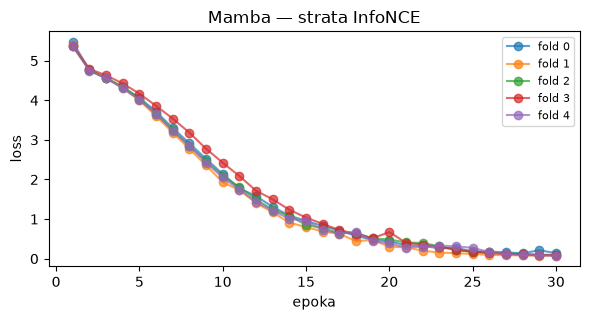

In [7]:
plot_hist(mamba_hist, 'Mamba — strata InfoNCE',
          'Wczytano gotowe wyniki — brak historii treningu (ustaw LOAD_PRETRAINED=False, by ją zobaczyć).')

## 6.3. Badanie hiperparametru — `d_model`

In [9]:
mamba_hp_df = hp_study(lambda C, T, **p: MambaModel(C, T, **p),
                       'd_model', [32, 64, 128, 256], {'d_state': 16}, 'mamba_hp_dmodel.csv')
mamba_hp_df

[d_model = 32]
[d_model = 64]
[d_model = 128]
[d_model = 256]


,d_model,Accuracy,ROC-AUC
0,32,0.5234,0.5254
1,64,0.5248,0.5257
2,128,0.5315,0.5330
3,256,0.5253,0.5277


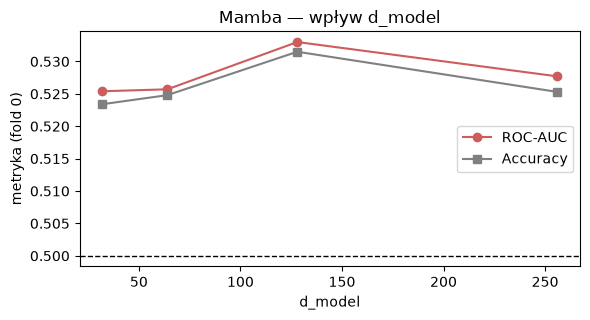

In [10]:
plt.figure(figsize=(6, 3.3))
plt.plot(mamba_hp_df['d_model'], mamba_hp_df['ROC-AUC'], marker='o', color='indianred', label='ROC-AUC')
plt.plot(mamba_hp_df['d_model'], mamba_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('Mamba — wpływ d_model'); plt.xlabel('d_model'); plt.ylabel('metryka (fold 0)')
plt.legend(); plt.tight_layout(); plt.show()

## 6.4. Badanie hiperparametru — `d_state`

In [11]:
mamba_hp_df = hp_study(lambda C, T, **p: MambaModel(C, T, **p),
                       'd_state', [8, 16, 32, 64], {'d_model': 64}, 'mamba_hp_dstate.csv')
mamba_hp_df

[d_state = 8]
[d_state = 16]
[d_state = 32]
[d_state = 64]


,d_state,Accuracy,ROC-AUC
0,8,0.5338,0.5241
1,16,0.5196,0.5252
2,32,0.5248,0.5226
3,64,0.5253,0.5221


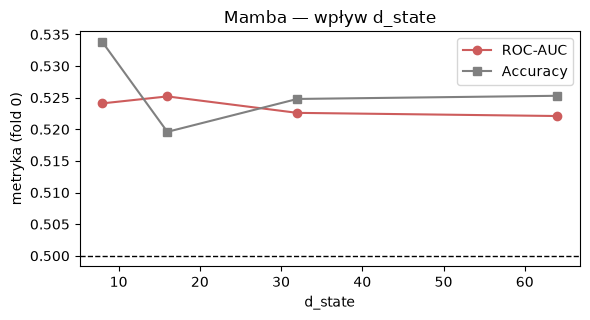

In [12]:
plt.figure(figsize=(6, 3.3))
plt.plot(mamba_hp_df['d_state'], mamba_hp_df['ROC-AUC'], marker='o', color='indianred', label='ROC-AUC')
plt.plot(mamba_hp_df['d_state'], mamba_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('Mamba — wpływ d_state'); plt.xlabel('d_state'); plt.ylabel('metryka (fold 0)')
plt.legend(); plt.tight_layout(); plt.show()

### Mamba z najlepszymi hiperparametrami — pełne CV
Najlepszy zestaw z random search dotrenowany na **pełnym CV**.

In [8]:
mamba_best_params = {
    'd_model': 128,
    'd_state': 16
}
print('Najlepsze HP Mamba:', mamba_best_params)
t0 = time.time()
mamba_best_acc, mamba_best_auc, mamba_best_hist = run_cv_smart(
    lambda C, T: MambaModel(C, T, **mamba_best_params),
    model_name='mamba', variant='mamba_best', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='mamba_best_hist.json', res_file='mamba_best.json',
)
print(f'\nMamba (najlepszy) | Acc {fmt(mamba_best_acc)} | AUC {fmt(mamba_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP Mamba: {'d_model': 128, 'd_state': 16}
[MAMBA_BEST] Wczytano zapisane wyniki (mamba_best.json) — bez treningu.

Mamba (najlepszy) | Acc 0.534 ± 0.011 | AUC 0.534 ± 0.014  (0s)


## 6.5. Wyniki i wnioski — Mamba

Mamba osiąga wyniki porównywalne z naiwnym baseline autoenkodera (AUC ~0.54), co wynika z niedostrzeżonej uprzednio niezgodności między skalą czasową architektury a skalą zjawisk w sygnale EEG.

Rekurencja SSM w MambaEncoder operuje wyłącznie wewnątrz pojedynczego okna – stan ukryty `h_t` akumuluje informację o 12 patchach reprezentujących łącznie 3 sekundy sygnału i jest resetowany dla każdego nowego okna. Tymczasem markery Alzheimera w EEG są zjawiskami rozgrywającymi się w skali dziesiątek sekund do minut, a więc między oknami, nie wewnątrz nich.

---
# 7. Podsumowanie zbiorcze

Tabela i wykres zestawiające metody w wariancie **domyślnym i najlepszym** (po optymalizacji hiperparametrów). Wymagana przez specyfikację tabela głównego eksperymentu z porównaniem do naiwnego baseline'u.

In [ ]:
summary = pd.DataFrame([
    {'Model': 'Baseline (AE)', 'Acc (domyślny)': fmt(ae_acc), 'AUC (domyślny)': fmt(ae_auc),
     'Acc (najlepszy)': '—', 'AUC (najlepszy)': '—', '_auc': np.mean(ae_auc)},
    {'Model': 'TNC', 'Acc (domyślny)': fmt(tnc_acc), 'AUC (domyślny)': fmt(tnc_auc),
     'Acc (najlepszy)': fmt(tnc_best_acc), 'AUC (najlepszy)': fmt(tnc_best_auc), '_auc': np.mean(tnc_best_auc)},
    {'Model': 'CPC', 'Acc (domyślny)': fmt(cpc_acc), 'AUC (domyślny)': fmt(cpc_auc),
     'Acc (najlepszy)': fmt(cpc_best_acc), 'AUC (najlepszy)': fmt(cpc_best_auc), '_auc': np.mean(cpc_best_auc)},
]).sort_values('_auc', ascending=False).drop(columns='_auc').reset_index(drop=True)
print('Tabela główna — klasyfikacja liniowa, AUC/Acc (średnia ± std po CV):')
print('("najlepszy" = po optymalizacji hiperparametrów random searchem)')
summary

In [ ]:
names    = ['Baseline (AE)', 'TNC', 'CPC']
auc_def  = [np.mean(ae_auc), np.mean(tnc_auc), np.mean(cpc_auc)]
std_def  = [np.std(ae_auc),  np.std(tnc_auc),  np.std(cpc_auc)]
auc_best = [np.mean(ae_auc), np.mean(tnc_best_auc), np.mean(cpc_best_auc)]
std_best = [np.std(ae_auc),  np.std(tnc_best_auc),  np.std(cpc_best_auc)]
x = np.arange(len(names)); w = 0.38
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, auc_def,  w, yerr=std_def,  capsize=5, label='domyślny', color='lightsteelblue', edgecolor='white')
plt.bar(x + w/2, auc_best, w, yerr=std_best, capsize=5, label='najlepszy (po opt. HP)', color='steelblue', edgecolor='white')
plt.axhline(0.5, ls='--', c='k', lw=1, label='losowy (AUC=0.5)')
plt.xticks(x, names); plt.ylabel('ROC-AUC (CV)'); plt.ylim(0, 1)
plt.title('Porównanie reprezentacji — klasyfikacja liniowa'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()